In [1]:
import pandas as pd
import numpy as np
import scipy
import matplotlib.pyplot as plt
import seaborn as sns

**1. Data Import and Cleaning**

In [2]:
air = pd.read_csv('/content/Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv', encoding='latin1')

In [3]:
air.head()

,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary
0,9/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,1.0,1.0,1.0,0.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,9/7/1909,NaN,"Juvisy-sur-Orge, France",NaN,NaN,Air show,Wright Byplane,SC1,NaN,1.0,0.0,1.0,1.0,0.0,0.0,0.0,Eugene Lefebvre was the first pilot to ever be...
2,7/12/1912,6:30,"Atlantic City, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,0.0,5.0,5.0,0.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
3,8/6/1913,NaN,"Victoria, British Columbia, Canada",Private,NaN,NaN,Curtiss seaplane,NaN,NaN,1.0,0.0,1.0,1.0,0.0,1.0,0.0,The first fatal airplane accident in Canada oc...
4,9/9/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,NaN,NaN,14.0,NaN,NaN,0.0,The airship flew into a thunderstorm and encou...


In [4]:
air.shape

(4998, 17)

In [5]:
air.columns

Index(['Date', 'Time', 'Location', 'Operator', 'Flight #', 'Route', 'AC Type',
       'Registration', 'cn/ln', 'Aboard', 'Aboard Passangers', 'Aboard Crew',
       'Fatalities', 'Fatalities Passangers', 'Fatalities Crew', 'Ground',
       'Summary'],
      dtype='object')

In [6]:
air.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4998 entries, 0 to 4997
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   4998 non-null   object 
 1   Time                   3486 non-null   object 
 2   Location               4994 non-null   object 
 3   Operator               4988 non-null   object 
 4   Flight #               1329 non-null   object 
 5   Route                  4221 non-null   object 
 6   AC Type                4983 non-null   object 
 7   Registration           4724 non-null   object 
 8   cn/ln                  4330 non-null   object 
 9   Aboard                 4980 non-null   float64
 10  Aboard Passangers      4769 non-null   float64
 11  Aboard Crew            4772 non-null   float64
 12  Fatalities             4990 non-null   float64
 13  Fatalities Passangers  4756 non-null   float64
 14  Fatalities Crew        4757 non-null   float64
 15  Grou

In [7]:
air.describe()

,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground
count,4980.000000,4769.000000,4772.000000,4990.000000,4756.000000,4757.000000,4956.000000
mean,31.195984,27.009017,4.479254,22.373547,19.053827,3.578516,1.719128
std,45.534788,44.111609,3.483859,35.061741,34.146127,3.167922,55.540273
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,3.000000,2.000000,4.000000,1.000000,2.000000,0.000000
50%,16.000000,12.000000,4.000000,11.000000,8.000000,3.000000,0.000000
75%,35.000000,30.000000,6.000000,25.000000,21.000000,5.000000,0.000000
max,644.000000,614.000000,61.000000,583.000000,560.000000,46.000000,2750.000000


In [8]:
print(f"The number of duplicates: {air.duplicated().sum()}")

The number of duplicates: 0


In [9]:
print(air.isna().sum())

Date                        0
Time                     1512
Location                    4
Operator                   10
Flight #                 3669
Route                     777
AC Type                    15
Registration              274
cn/ln                     668
Aboard                     18
Aboard Passangers         229
Aboard Crew               226
Fatalities                  8
Fatalities Passangers     242
Fatalities Crew           241
Ground                     42
Summary                    64
dtype: int64


Since more than 50% of the data is missing in the 'Flight #' column we can drop all column.
For those columns where the missing values is less than 1% we will drop the rows.
For the rest we will fill the null values with median and mode.

In [10]:
df = air.copy()
df = df.drop(columns=['Flight #'])

In [11]:
df = df.dropna(subset=['Location', 'Fatalities', 'AC Type', 'Aboard'])

In [12]:
print(df.isna().sum())

Date                        0
Time                     1480
Location                    0
Operator                    7
Route                     751
AC Type                     0
Registration              251
cn/ln                     639
Aboard                      0
Aboard Passangers         204
Aboard Crew               201
Fatalities                  0
Fatalities Passangers     220
Fatalities Crew           218
Ground                     29
Summary                    53
dtype: int64


In [13]:
df['Time'] = df['Time'].fillna(df['Time'].mode()[0])
df['Operator'] = df['Operator'].fillna(df['Operator'].mode()[0])
df['Route'] = df['Route'].fillna(df['Route'].mode()[0])
df['Registration'] = df['Registration'].fillna(df['Registration'].mode()[0])
df['cn/ln'] = df['cn/ln'].fillna(df['cn/ln'].mode()[0])

In [28]:
print(df.isna().sum())

Date                       0
Time                       0
Location                   0
Operator                   0
Route                      0
AC Type                    0
Registration               0
cn/ln                      0
Aboard                     0
Aboard Passangers        204
Aboard Crew              201
Fatalities                 0
Fatalities Passangers    220
Fatalities Crew          218
Ground                    29
Summary                   53
dtype: int64


In [14]:
df['Aboard Passangers'] = df['Aboard Passangers'].fillna(df['Aboard Passangers'].median())
df['Aboard Crew'] = df['Aboard Crew'].fillna(df['Aboard Crew'].median())
df['Fatalities Passangers'] = df['Aboard Crew'].fillna(df['Aboard Crew'].median())
df['Fatalities Crew'] = df['Fatalities Crew'].fillna(df['Fatalities Crew'].median())
df['Ground'] = df['Ground'].fillna(df['Ground'].median())

In [19]:
df['Summary'] = df['Summary'].fillna("Summary")

In [20]:
print(df.isna().sum())

Date                     0
Time                     0
Location                 0
Operator                 0
Route                    0
AC Type                  0
Registration             0
cn/ln                    0
Aboard                   0
Aboard Passangers        0
Aboard Crew              0
Fatalities               0
Fatalities Passangers    0
Fatalities Crew          0
Ground                   0
Summary                  0
dtype: int64


In [22]:
df['Date'] = pd.to_datetime(df['Date'])

In [27]:
df['Time'] = df['Time'].apply(lambda x: x if x.count(':') == 2 else x + ':00')
df['Time'] = pd.to_timedelta(df['Time'])

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4964 entries, 0 to 4997
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype          
---  ------                 --------------  -----          
 0   Date                   4964 non-null   datetime64[ns] 
 1   Time                   4964 non-null   timedelta64[ns]
 2   Location               4964 non-null   object         
 3   Operator               4964 non-null   object         
 4   Route                  4964 non-null   object         
 5   AC Type                4964 non-null   object         
 6   Registration           4964 non-null   object         
 7   cn/ln                  4964 non-null   object         
 8   Aboard                 4964 non-null   float64        
 9   Aboard Passangers      4964 non-null   float64        
 10  Aboard Crew            4964 non-null   float64        
 11  Fatalities             4964 non-null   float64        
 12  Fatalities Passangers  4964 non-null   float64       

In [30]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Hour'] = df['Time'].dt.components.hours
df['Minute'] = df['Time'].dt.components.minutes

In [32]:
df.head()

,Date,Time,Location,Operator,Route,AC Type,Registration,cn/ln,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary,Year,Month,Hour,Minute
0,1908-09-17,0 days 17:18:00,"Fort Myer, Virginia",Military - U.S. Army,Demonstration,Wright Flyer III,19,1,2.0,1.0,1.0,1.0,1.0,0.0,0.0,"During a demonstration flight, a U.S. Army fly...",1908,9,17,18
1,1909-09-07,0 days 15:00:00,"Juvisy-sur-Orge, France",Aeroflot,Air show,Wright Byplane,SC1,1,1.0,0.0,1.0,1.0,1.0,0.0,0.0,Eugene Lefebvre was the first pilot to ever be...,1909,9,15,0
2,1912-07-12,0 days 06:30:00,"Atlantic City, New Jersey",Military - U.S. Navy,Test flight,Dirigible,19,1,5.0,0.0,5.0,5.0,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...,1912,7,6,30
3,1913-08-06,0 days 15:00:00,"Victoria, British Columbia, Canada",Private,Training,Curtiss seaplane,19,1,1.0,0.0,1.0,1.0,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...,1913,8,15,0
4,1913-09-09,0 days 18:30:00,Over the North Sea,Military - German Navy,Training,Zeppelin L-1 (airship),19,1,20.0,12.0,4.0,14.0,4.0,3.0,0.0,The airship flew into a thunderstorm and encou...,1913,9,18,30


**2. Exploratory Data Analysis**

In [33]:
total_crashes = len(df)
print(f"Total crashes: {total_crashes}")

Total crashes: 4964


In [34]:
total_fatalities = df['Fatalities'].sum()
print(f"Total fatalities: {total_fatalities}")

Total fatalities: 111376.0


In [35]:
total_aboard = df['Aboard'].sum()
print(f"Total people aboard: {total_aboard}")

Total people aboard: 155166.0


In [36]:
survival_rate = (total_aboard - total_fatalities) / total_aboard
print(f"Survival rate: {survival_rate}")

Survival rate: 0.28221388706288747


In [38]:
crashes_per_year = df.groupby('Year').size().sort_values(ascending=False)
print(crashes_per_year.head())

Year
1946    85
1989    82
1947    81
1962    77
1948    77
dtype: int64


**3. Statistical Analysis**

In [40]:
import numpy as np

mean_fatalities = np.mean(df['Fatalities'])
median_fatalities = np.median(df['Fatalities'])
std_fatalities = np.std(df['Fatalities'])

print(f"Mean: {mean_fatalities}")
print(f"Median: {median_fatalities}")
print(f"Standard deviation: {std_fatalities}")

Mean: 22.436744560838033
Median: 11.0
Standard deviation: 35.12477223922459


In [41]:
df['survival_rate'] = (df['Aboard'] - df['Fatalities']) / df['Aboard']

In [42]:
df['survival_rate'].describe()

,survival_rate
count,4959.000000
mean,0.181839
std,0.312041
min,0.000000
25%,0.000000
50%,0.000000
75%,0.250000
max,1.000000


In [43]:
df['Decade'] = (df['Year'] // 10) * 10

In [44]:
from scipy import stats

fatal_1970 = df[df['Decade'] == 1970]['Fatalities']
fatal_2000 = df[df['Decade'] == 2000]['Fatalities']

t_stat, p_value = stats.ttest_ind(fatal_1970, fatal_2000, nan_policy='omit')

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 3.94280760280891
P-value: 8.555287989947047e-05


In [45]:
print(f"Top crash lications:\n{df['Location'].value_counts().head(10)}")

Top crash lications:
Location
Moscow, Russia            16
Manila, Philippines       15
New York, New York        14
Sao Paulo, Brazil         13
Cairo, Egypt              13
Rio de Janeiro, Brazil    12
Bogota, Colombia          12
Near Moscow, Russia       11
Tehran, Iran              10
Chicago, Illinois         10
Name: count, dtype: int64


In [46]:
print(f"Top Deadliest operators:\n{df.groupby('Operator')['Fatalities'].sum().sort_values(ascending=False).head(10)}")

Top Deadliest operators:
Operator
Aeroflot                           8827.0
Military - U.S. Air Force          3356.0
Air France                         1756.0
American Airlines                  1422.0
Pan American World Airways         1303.0
Military - U.S. Army Air Forces    1070.0
United Air Lines                   1019.0
AVIANCA                             941.0
Turkish Airlines (THY)              890.0
Indian Airlines                     860.0
Name: Fatalities, dtype: float64


**4. Visualization**

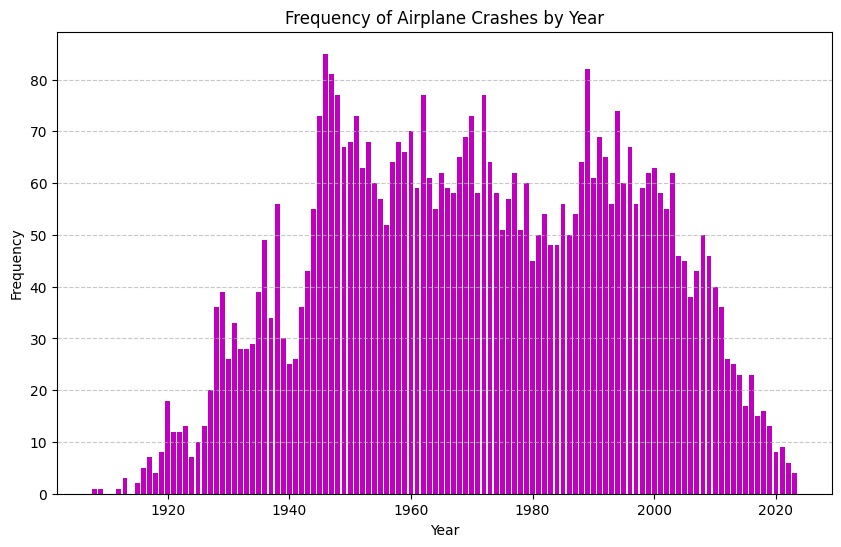

In [48]:
frequency_of_aircrash = df['Year'].value_counts().sort_index()


plt.figure(figsize=(10, 6))
plt.bar(frequency_of_aircrash.index, frequency_of_aircrash.values, color='m')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.title('Frequency of Airplane Crashes by Year')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

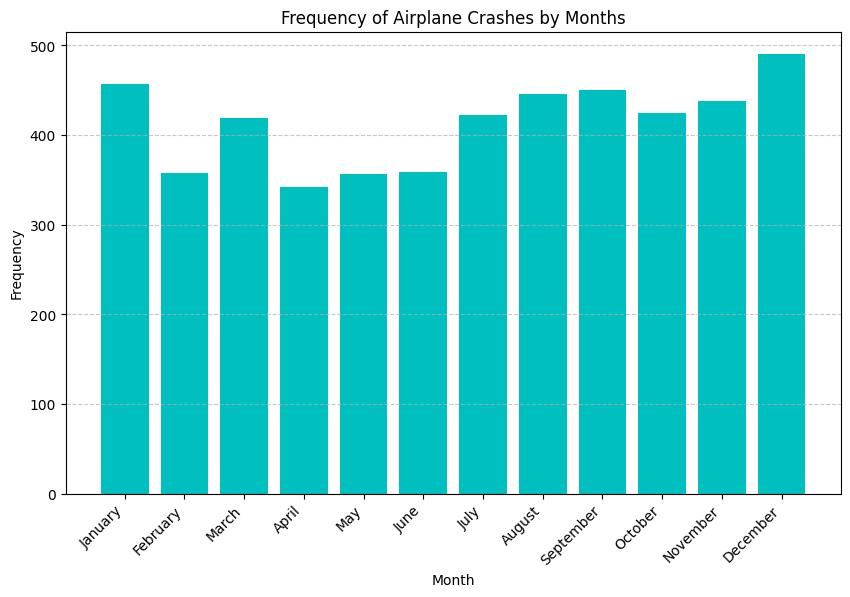

In [50]:
import calendar

frequency_of_aircrash_mnth = df['Month'].value_counts().sort_index()

month_names = [calendar.month_name[i] for i in frequency_of_aircrash_mnth.index]

plt.figure(figsize=(10, 6))
plt.bar(month_names, frequency_of_aircrash_mnth.values, color='c')
plt.xlabel('Month')
plt.ylabel('Frequency')
plt.title('Frequency of Airplane Crashes by Months')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.show()

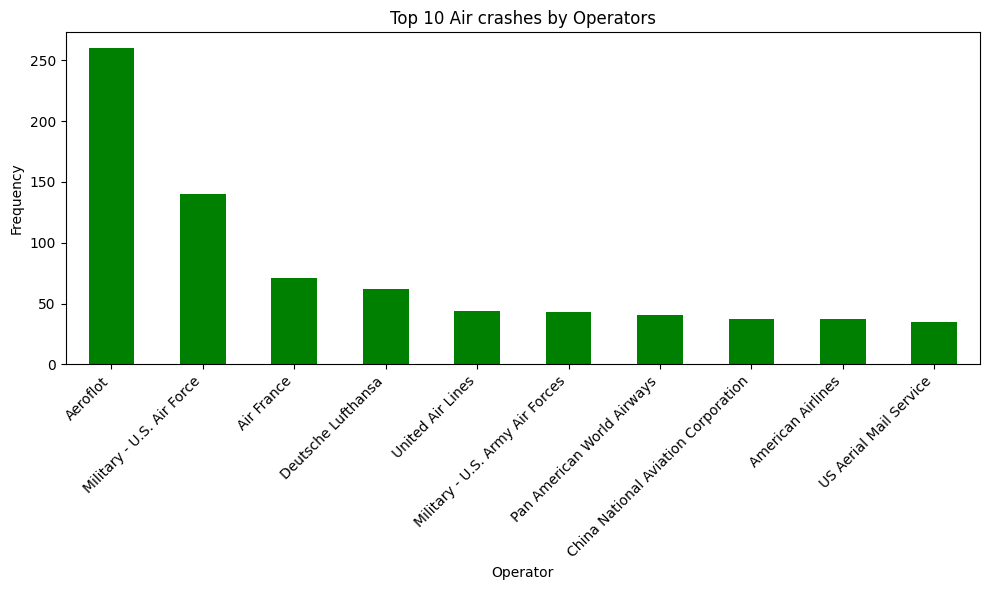

In [51]:
operator_frequency = df['Operator'].value_counts().head(10)

plt.figure(figsize=(10, 6))
operator_frequency.plot(kind='bar', color='green')
plt.xlabel('Operator')
plt.ylabel('Frequency')
plt.title('Top 10 Air crashes by Operators')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

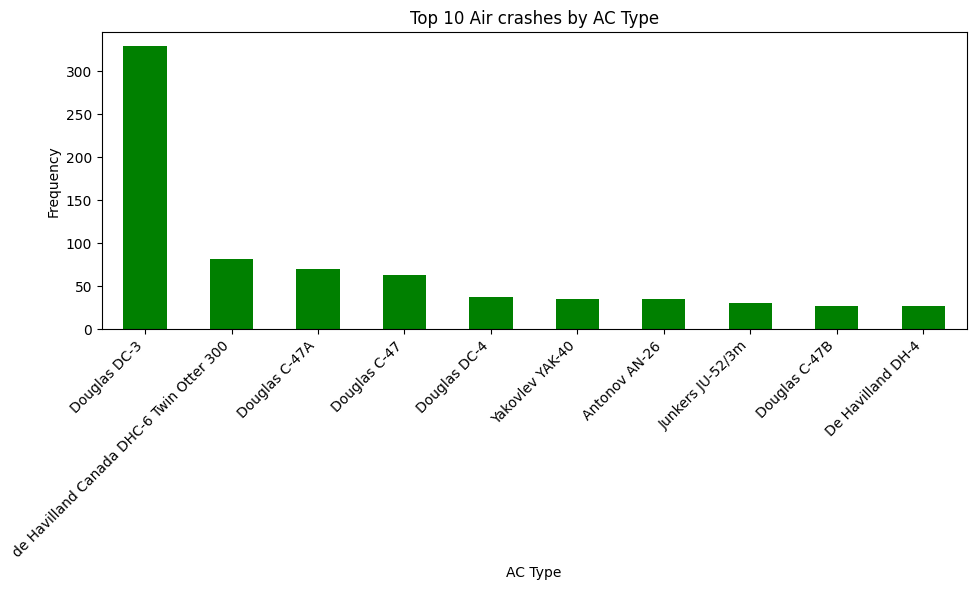

In [52]:
ac_type_frequency = df['AC Type'].value_counts().head(10)

plt.figure(figsize=(10, 6))
ac_type_frequency.plot(kind='bar', color='green')
plt.xlabel('AC Type')
plt.ylabel('Frequency')
plt.title('Top 10 Air crashes by AC Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

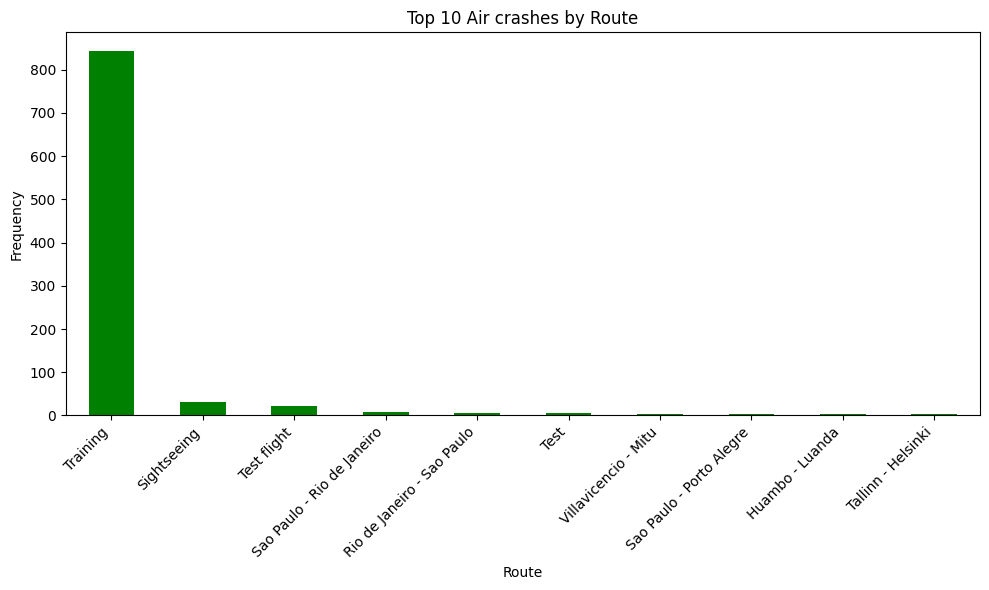

In [53]:
route_frequency = df['Route'].value_counts().head(10)

plt.figure(figsize=(10, 6))
route_frequency .plot(kind='bar', color='green')
plt.xlabel('Route')
plt.ylabel('Frequency')
plt.title('Top 10 Air crashes by Route')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

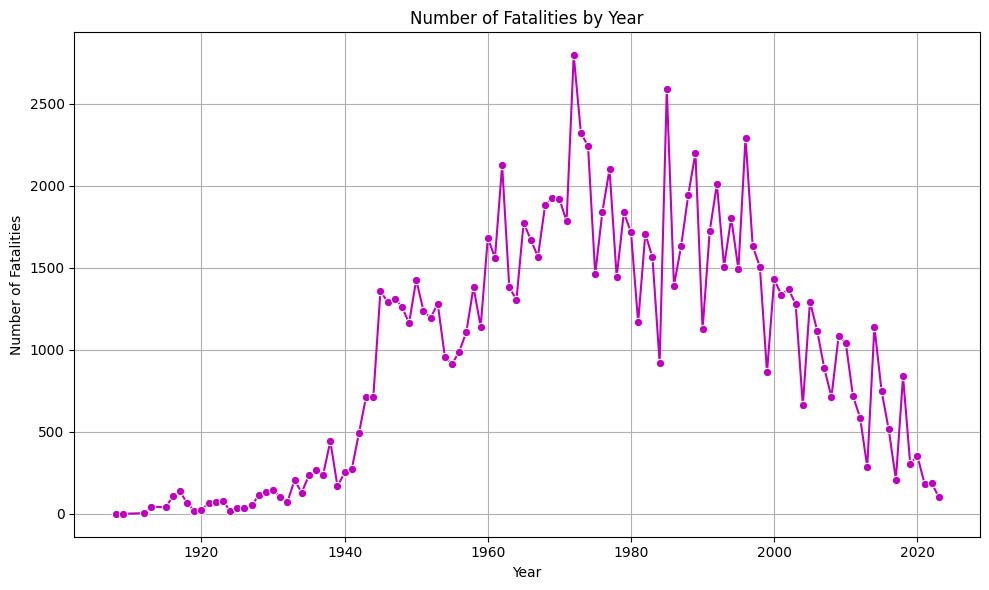

In [54]:
fatalities_by_year = df.groupby(df['Year'])['Fatalities'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=fatalities_by_year, x='Year', y='Fatalities', marker='o', color='m')
plt.xlabel('Year')
plt.ylabel('Number of Fatalities')
plt.title('Number of Fatalities by Year')
plt.grid(True)
plt.tight_layout()

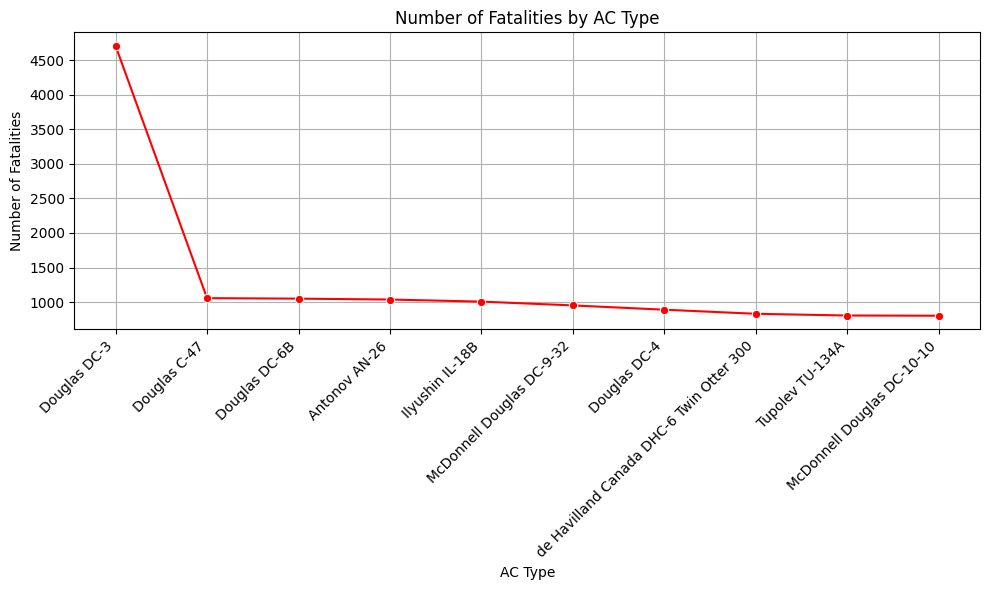

In [55]:
fatalities_ac_type = df.groupby(df['AC Type'])['Fatalities'].sum().reset_index()

top_10_ac_types = fatalities_ac_type.nlargest(10, 'Fatalities')

plt.figure(figsize=(10, 6))
sns.lineplot(data=top_10_ac_types, x='AC Type', y='Fatalities', marker='o', color='r')
plt.xlabel('AC Type')
plt.ylabel('Number of Fatalities')
plt.title('Number of Fatalities by AC Type')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()

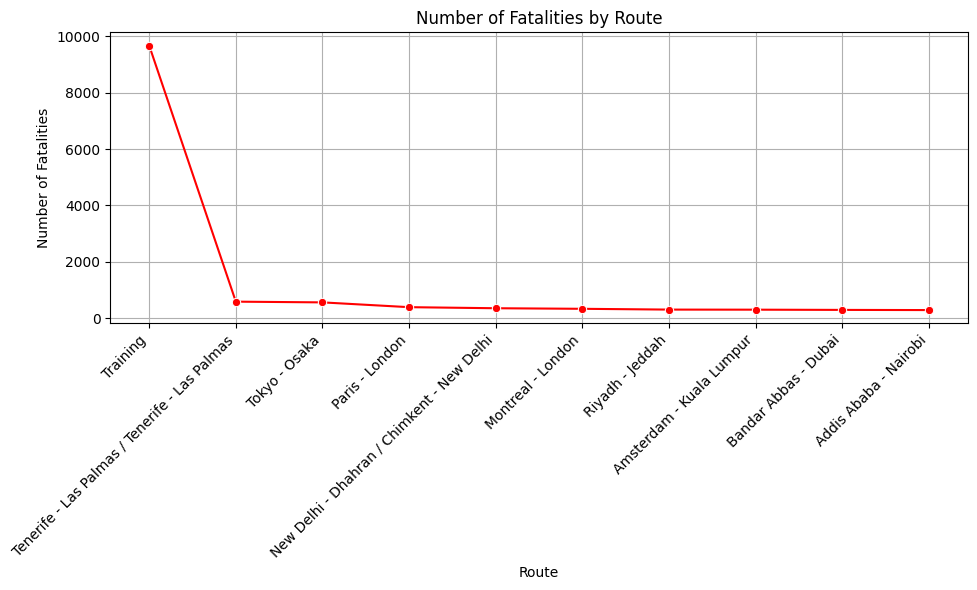

In [56]:
fatalities_route = df.groupby(df['Route'])['Fatalities'].sum().reset_index()

top_10_routes = fatalities_route.nlargest(10, 'Fatalities')

plt.figure(figsize=(10, 6))
sns.lineplot(data=top_10_routes, x='Route', y='Fatalities', marker='o', color='r')
plt.xlabel('Route')
plt.ylabel('Number of Fatalities')
plt.title('Number of Fatalities by Route')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()

**5. Insight and Report**

We can observe a rise in the frequency of air crashes starting from 1920, with a significant decrease only noticeable from 2011. However, it is unclear whether this is a consequence of increased air traffic or other factors. Similarly, the substantial decrease in aircraft incidents from 2020 may be related to the reduction in flights due to the COVID-19 pandemic and subsequent bankruptcies of major airlines, which naturally affected flight numbers post-pandemic.

There are no significant differences in frequency between months, indicating that the timing of flights does not affect the likelihood of a crash. Even a slight increase in frequency in December cannot be directly attributed to weather conditions or other factors, as it may be due to heightened holiday travel during Christmas and New Year.

Regarding the top 10 air crash frequencies by operators, it is unclear whether this reflects the quality of planes, engines, etc., or if it is a result of measurement errors that do not consider the percentage of air crashes relative to the total number of flights operated by each airline. However, it is worth noting the notably high frequency of air crashes associated with the Aeroflot operator, as well as the Douglas DC-3 aircraft type, which also exhibits a high frequency of crashes.

Additionally, there appears to be a higher probability of air crashes during training, sightseeing, or test flights.